In [133]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
from PIL import Image
import shutil
from pathlib import Path

**Root**

In [46]:
root_path = r"D:\Project\CPV_paper\datasets\raw\NICO++\DG_Benchmark\NICO_DG"
root = os.listdir(root_path)

**Dataset overview**

In [47]:
rows = []

for domain in os.listdir(root_path):
    domain_path = os.path.join(root_path, domain)

    if not os.path.isdir(domain_path):
        continue

    for category in os.listdir(domain_path):
        category_path = os.path.join(domain_path, category)

        if not os.path.isdir(category_path):
            continue

        for image in os.listdir(category_path):
            image_path = os.path.join(category_path, image)

            if not os.path.isfile(image_path):
                continue

            rows.append({
                "image_path": image_path,
                "image_name": image,
                "domain": domain,
                "category": category
            })

df = pd.DataFrame(rows)

df.head()

,image_path,image_name,domain,category
0,D:\Project\CPV_paper\datasets\raw\NICO++\DG_Be...,autumn_0000001.jpg,autumn,airplane
1,D:\Project\CPV_paper\datasets\raw\NICO++\DG_Be...,autumn_0000002.jpg,autumn,airplane
2,D:\Project\CPV_paper\datasets\raw\NICO++\DG_Be...,autumn_0000003.jpg,autumn,airplane
3,D:\Project\CPV_paper\datasets\raw\NICO++\DG_Be...,autumn_0000004.jpg,autumn,airplane
4,D:\Project\CPV_paper\datasets\raw\NICO++\DG_Be...,autumn_0000005.jpg,autumn,airplane


In [8]:
print(f"""
Number of domains: {len(df['domain'].unique())}
{df['domain'].unique()}

Number of categories: {len(df['category'].unique())}
{df['category'].unique()}

Number of images: {len(df)}
""")


Number of domains: 6
['autumn' 'dim' 'grass' 'outdoor' 'rock' 'water']

Number of categories: 60
['airplane' 'bear' 'bicycle' 'bird' 'bus' 'butterfly' 'cactus' 'car' 'cat'
 'chair' 'clock' 'corn' 'cow' 'crab' 'crocodile' 'dog' 'dolphin'
 'elephant' 'fishing rod' 'flower' 'football' 'fox' 'frog' 'giraffe'
 'goose' 'gun' 'hat' 'helicopter' 'horse' 'hot air balloon' 'kangaroo'
 'lifeboat' 'lion' 'lizard' 'mailbox' 'monkey' 'motorcycle' 'ostrich'
 'owl' 'pineapple' 'pumpkin' 'rabbit' 'racket' 'sailboat' 'scooter' 'seal'
 'sheep' 'ship' 'shrimp' 'spider' 'squirrel' 'sunflower' 'tent' 'tiger'
 'tortoise' 'train' 'truck' 'umbrella' 'wheat' 'wolf']

Number of images: 88866



**Domain distribution**

In [59]:
def bar_plot(x, y, x_label, y_label, title, data):
    plt.figure(figsize=(20, 5))
    sns.barplot(x=x, y=y, data=data, hue=x, palette='viridis')
    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.tight_layout()
    plt.plot()


Image per domain:
    domain  count
0    grass  20327
1    water  19202
2  outdoor  16690
3      dim  12489
4     rock  11064
5   autumn   9094

Largest domain:
domain    1
count     0
dtype: int64

Smallest domain:
domain    5
count     5
dtype: int64

Imbalance ratio:
2.24



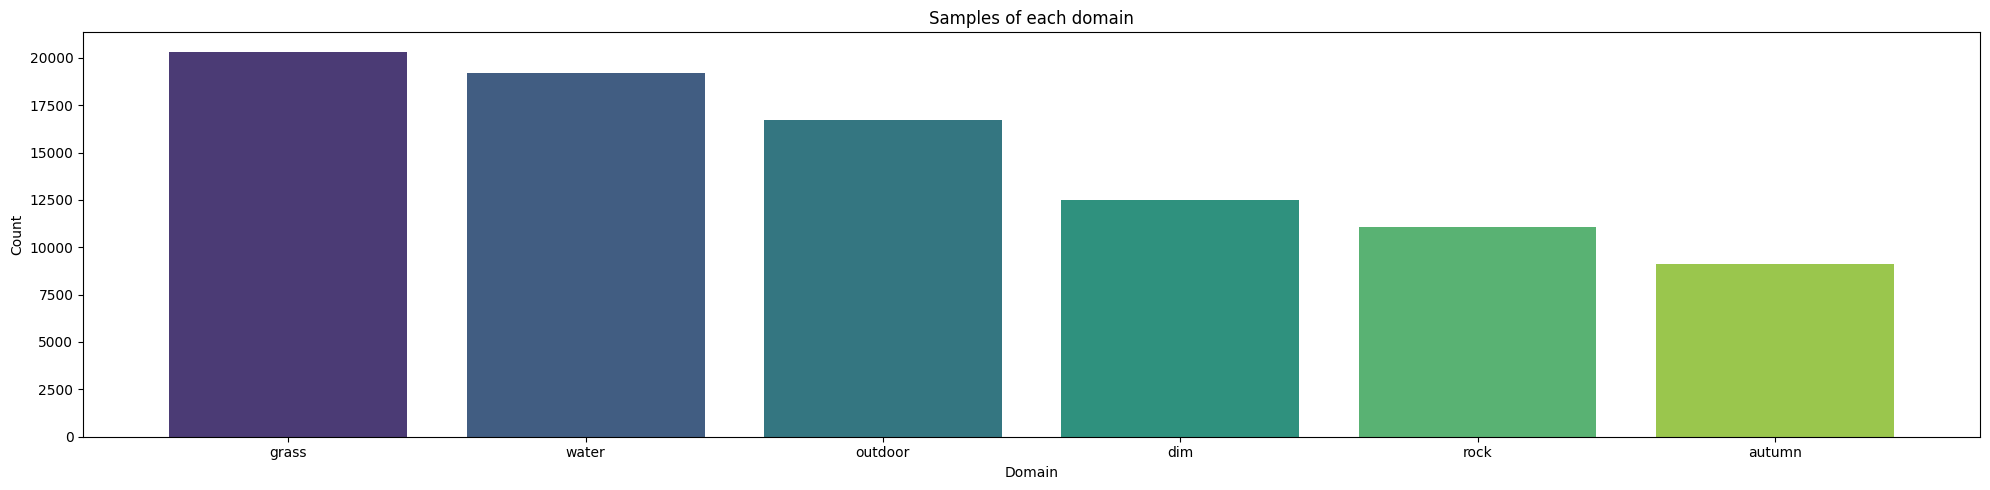

In [60]:
domain_counts = df['domain'].value_counts().reset_index()

print(f"""
Image per domain:
{domain_counts}

Largest domain:
{domain_counts.idxmax()}

Smallest domain:
{domain_counts.idxmin()}

Imbalance ratio:
{domain_counts['count'].max() / domain_counts['count'].min():.2f}
""")

bar_plot('domain', 'count', 'Domain', 'Count', 'Samples of each domain', domain_counts)

**Class distribution**


Top frequent classes:
     category  count
0         dog   2703
1        bird   2299
2         cow   2162
3       sheep   2036
4     bicycle   2024
5         cat   1991
6  motorcycle   1942
7        tent   1913
8       horse   1849
9        bear   1848

Rare classes:
     category  count
50    mailbox   1031
51    dolphin   1027
52    scooter    992
53   football    962
54      wheat    922
55       crab    910
56       corn    908
57  pineapple    885
58     racket    830
59     shrimp    560

Imbalance ratio:
4.83



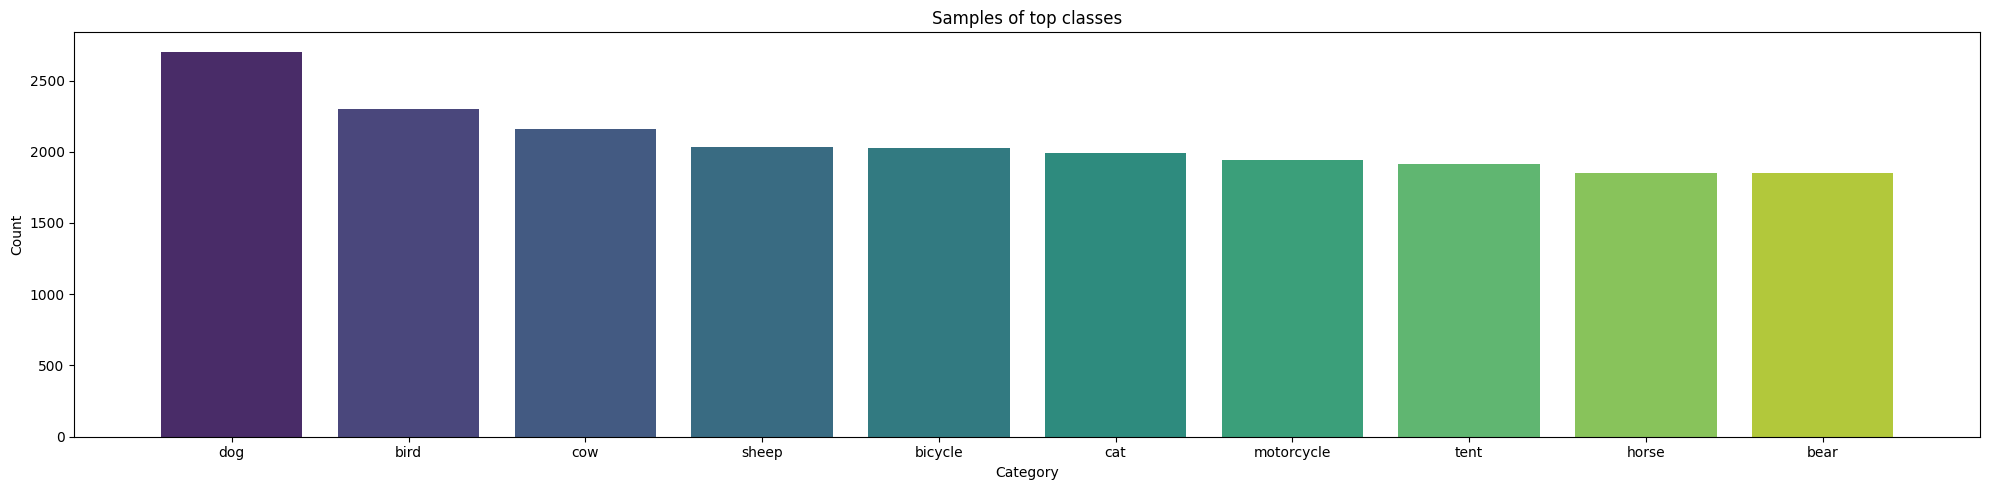

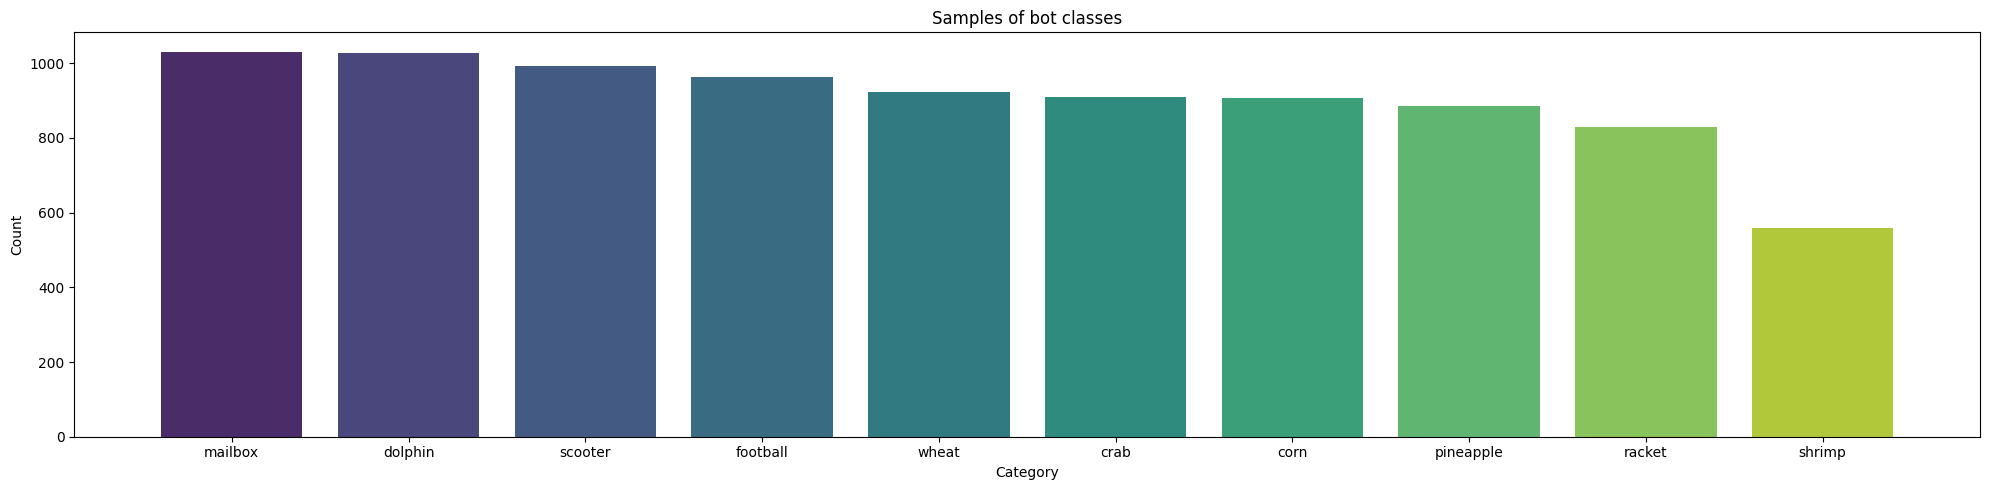

In [61]:
class_counts = df['category'].value_counts().reset_index()

print(f"""
Top frequent classes:
{class_counts.head(10)}

Rare classes:
{class_counts.tail(10)}

Imbalance ratio:
{class_counts['count'].max() / class_counts['count'].min():.2f}
""")

bar_plot('category', 'count', 'Category', 'Count', 'Samples of top classes', class_counts.head(10))
bar_plot('category', 'count', 'Category', 'Count', 'Samples of bot classes', class_counts.tail(10))

**Visual domain shift**

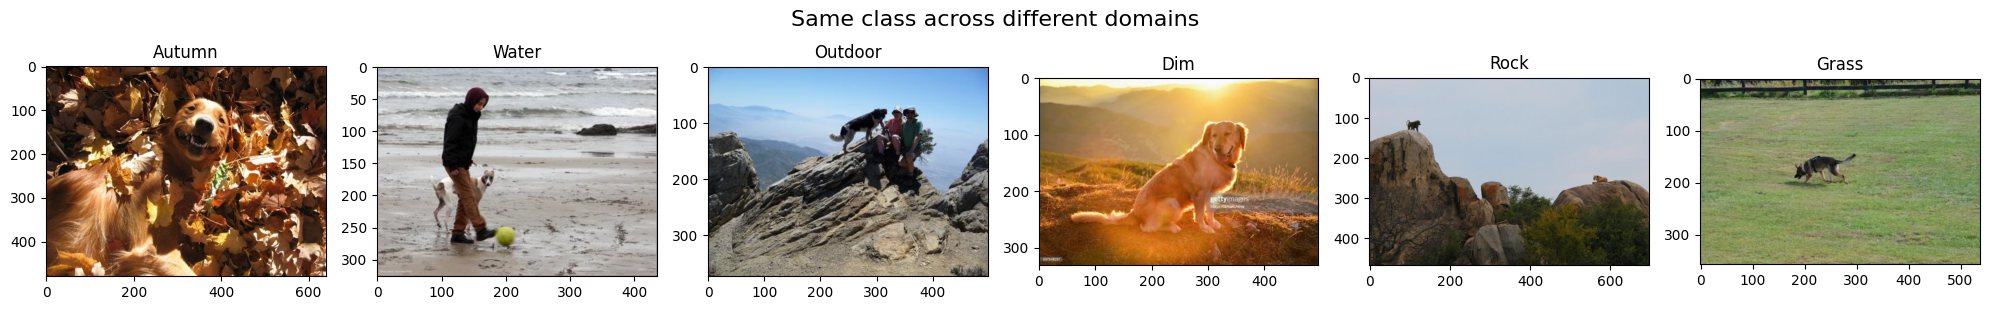

In [62]:
idx = 67
fig, ax = plt.subplots(1, 6, figsize=(20, 3))

ax[0].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'autumn')]['image_path'].iloc[idx]))
ax[0].set_title('Autumn')

ax[1].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'water')]['image_path'].iloc[idx]))
ax[1].set_title('Water')

ax[2].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'outdoor')]['image_path'].iloc[idx]))
ax[2].set_title('Outdoor')

ax[3].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'dim')]['image_path'].iloc[idx]))
ax[3].set_title('Dim')

ax[4].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'rock')]['image_path'].iloc[idx]))
ax[4].set_title('Rock')

ax[5].imshow(Image.open(df[(df['category'] == 'dog') & (df['domain'] == 'grass')]['image_path'].iloc[idx]))
ax[5].set_title('Grass')

plt.suptitle("Same class across different domains", fontsize=16)
plt.tight_layout()
plt.show()

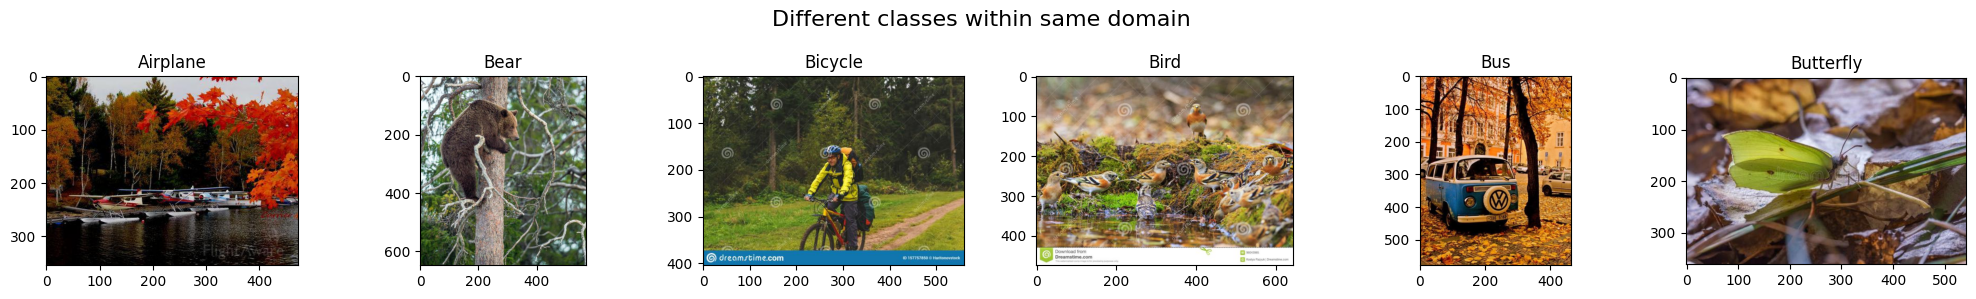

In [63]:
idx = 36
fig, ax = plt.subplots(1, 6, figsize=(20, 3))

ax[0].imshow(Image.open(df[(df['category'] == 'airplane') & (df['domain'] == 'autumn')]['image_path'].iloc[idx]))
ax[0].set_title('Airplane')

ax[1].imshow(Image.open(df[(df['category'] == 'bear') & (df['domain'] == 'autumn')]['image_path'].iloc[idx]))
ax[1].set_title('Bear')

ax[2].imshow(Image.open(df[(df['category'] == 'bicycle') & (df['domain'] == 'autumn')]['image_path'].iloc[idx]))
ax[2].set_title('Bicycle')

ax[3].imshow(Image.open(df[(df['category'] == 'bird') & (df['domain'] == 'autumn')]['image_path'].iloc[idx]))
ax[3].set_title('Bird')

ax[4].imshow(Image.open(df[(df['category'] == 'bus') & (df['domain'] == 'autumn')]['image_path'].iloc[idx]))
ax[4].set_title('Bus')

ax[5].imshow(Image.open(df[(df['category'] == 'butterfly') & (df['domain'] == 'autumn')]['image_path'].iloc[idx]))
ax[5].set_title('Butterfly')

plt.suptitle("Different classes within same domain", fontsize=16)
plt.tight_layout()
plt.show()

**Image quality**

In [64]:
widths, heights, aspect_ratios, corrupt = [], [], [], []

for path in df['image_path']:
    try:
        with Image.open(path) as img:
            img.verify()

        with Image.open(path) as img:
            w, h = img.size

        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w/h)
        corrupt.append(False)

    except Exception:
        widths.append(None)
        heights.append(None)
        aspect_ratios.append(None)
        corrupt.append(True)

df = df.copy()
df["width"] = widths
df["height"] = heights
df["aspect_ratio"] = aspect_ratios
df["corrupt"] = corrupt

In [65]:
df.head()

,image_path,image_name,domain,category,width,height,aspect_ratio,corrupt
0,D:\Project\CPV_paper\datasets\raw\NICO++\DG_Be...,autumn_0000001.jpg,autumn,airplane,1300,487,2.669405,False
1,D:\Project\CPV_paper\datasets\raw\NICO++\DG_Be...,autumn_0000002.jpg,autumn,airplane,390,280,1.392857,False
2,D:\Project\CPV_paper\datasets\raw\NICO++\DG_Be...,autumn_0000003.jpg,autumn,airplane,628,440,1.427273,False
3,D:\Project\CPV_paper\datasets\raw\NICO++\DG_Be...,autumn_0000004.jpg,autumn,airplane,473,355,1.332394,False
4,D:\Project\CPV_paper\datasets\raw\NICO++\DG_Be...,autumn_0000005.jpg,autumn,airplane,400,359,1.114206,False


In [68]:
print(f"""
Image sizes stats:
{df[["width", "height", "aspect_ratio"]].describe()}

Corrupt images:
{df[df["corrupt"] == True][["image_path", "domain", "category"]]}

Small images:
{df[(df["width"] < 32) | (df["height"] < 32)][["image_path", "domain", "category", "width", "height"]]}

Strange aspect ratios images:
{df[(df["aspect_ratio"] < 0.3) | (df["aspect_ratio"] > 3.0)][["image_path", "domain", "category", "width", "height", "aspect_ratio"]].value_counts().sum()}
""")


Image sizes stats:
              width        height  aspect_ratio
count  88866.000000  88866.000000  88866.000000
mean     590.771645    451.425315      1.359404
std      165.268411    129.912196      0.352321
min       45.000000     50.000000      0.148561
25%      483.000000    367.000000      1.330409
50%      578.000000    428.000000      1.395349
75%      673.000000    503.000000      1.501633
max     3872.000000   4293.000000      8.258065

Corrupt images:
Empty DataFrame
Columns: [image_path, domain, category]
Index: []

Small images:
Empty DataFrame
Columns: [image_path, domain, category, width, height]
Index: []

Strange aspect ratios images:
167



**Split quality**

In [75]:
split_path = r"D:\Project\CPV_paper\datasets\raw\NICO++\DG_Benchmark\NICO_DG_official"
split = os.listdir(split_path)

In [ ]:
rows = []

for txt in split:
    txt_path = os.path.join(split_path, txt)
    domain = txt.split('_')[0]
    split2 = "train" if "train" in txt else "test"

    with open(txt_path, 'r') as f:
        contents = f.readlines()
        
        for content in contents:
            rows.append({
                "image_path": ' '.join(content.split()[:-1]) if len(content.split()) > 2 else content.split()[0],
                "domain": domain,
                "split": split2,
                "label": content.split()[-1]
            })

In [114]:
df = pd.DataFrame(rows)

df.head()

,image_path,domain,split,label
0,NICO_DG/autumn/cow/autumn_000179.jpg,autumn,test,15
1,NICO_DG/autumn/chair/autumn_000114.jpg,autumn,test,2
2,NICO_DG/autumn/wolf/autumn_000105.jpg,autumn,test,7
3,NICO_DG/autumn/frog/autumn_000103.jpg,autumn,test,50
4,NICO_DG/autumn/train/autumn_000155.jpg,autumn,test,39


In [115]:
print(f"""
Train size:
{len(df[df['split'] == 'train'])}

Test size:
{len(df[df['split'] == 'test'])}

Class balance per split:
{pd.crosstab(df["label"], df["split"]).head()}

Domain balance per split:
{pd.crosstab(df["domain"], df["split"]).head()}
""")


Train size:
71091

Test size:
17775

Class balance per split:
split  test  train
label             
0       340   1480
1       376   1413
10      267   1041
11      187    721
12      356   1442

Domain balance per split:
split    test  train
domain              
autumn   1819   7275
dim      2498   9991
grass    4066  16261
outdoor  3338  13352
rock     2213   8851



**Domain Generalization Protocol**

In [116]:
def source_target_plot(target_domains):
    target_df = df[df['domain'].isin(target_domains)]
    source_df = df[~df['domain'].isin(target_domains)]

    target_split = target_df.groupby('split')['domain'].value_counts().reset_index()
    source_split = source_df.groupby('split')['domain'].value_counts().reset_index()

    target_split["dataset"] = "target"
    source_split["dataset"] = "source"

    plot_df = pd.concat([source_split, target_split], ignore_index=True)

    plot_df["group"] = (plot_df["dataset"].str.capitalize() + " - " + plot_df["split"].str.capitalize())

    domain_order = (plot_df.groupby("domain")["count"].sum().sort_values(ascending=False).index)

    plt.figure(figsize=(20, 5))

    ax = sns.barplot(data=plot_df,x="domain",y="count",hue="group",order=domain_order)

    plt.title("Train/Test Distribution for Source and Target Domains")
    plt.xlabel("Domain")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=30)
    plt.legend(title="Dataset Split")
    plt.tight_layout()
    plt.show()

    return source_df, target_df

**Case 1**

In [165]:
def copy_images(df, root_path, output_path):
    root_path = Path(root_path)
    output_path = Path(output_path)
    output_path.mkdir(parents=True, exist_ok=True)

    for image_path in df["image_path"]:
        parts = image_path.split("/")

        domain = parts[1]
        category = parts[2]

        src = root_path / image_path
        dst_dir = output_path / domain / category

        dst_dir.mkdir(parents=True, exist_ok=True)

        shutil.copy2(src, dst_dir)

In [172]:
root_path = Path(r"D:\Project\CPV_paper\datasets\raw\NICO++\DG_Benchmark")

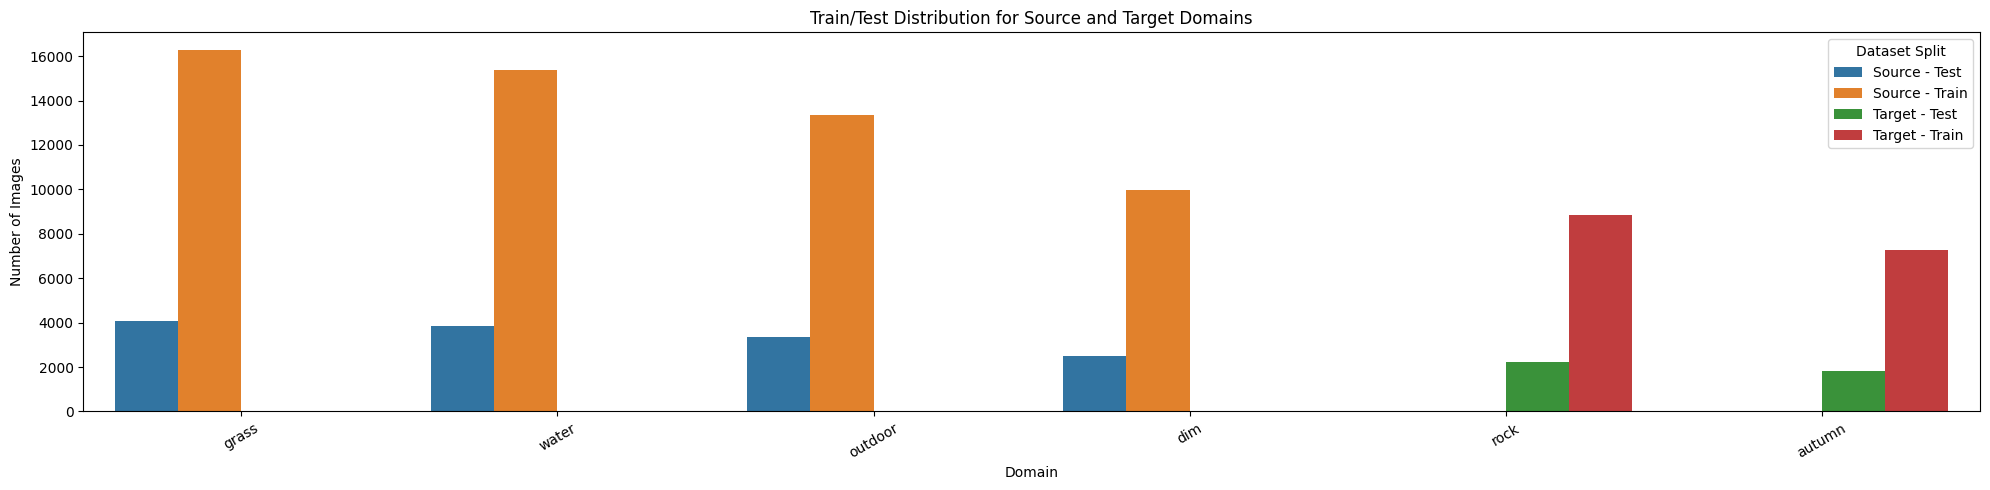

In [117]:
target_domains = ['autumn', 'rock']
source_df, target_df = source_target_plot(target_domains)

In [ ]:
target_path = Path(r"D:\Project\CPV_paper\datasets\processed\NICO++\autumn_rock")

target_train_df = target_df[target_df["split"] == "train"]
target_test_df = target_df[target_df["split"] == "test"]

target_train_path = target_path / "train"
target_test_path = target_path / "test"

target_train_path.mkdir(parents=True, exist_ok=True)
target_test_path.mkdir(parents=True, exist_ok=True)

copy_images(target_train_df, root_path, target_train_path)
copy_images(target_test_df, root_path, target_test_path)

**Case 2**

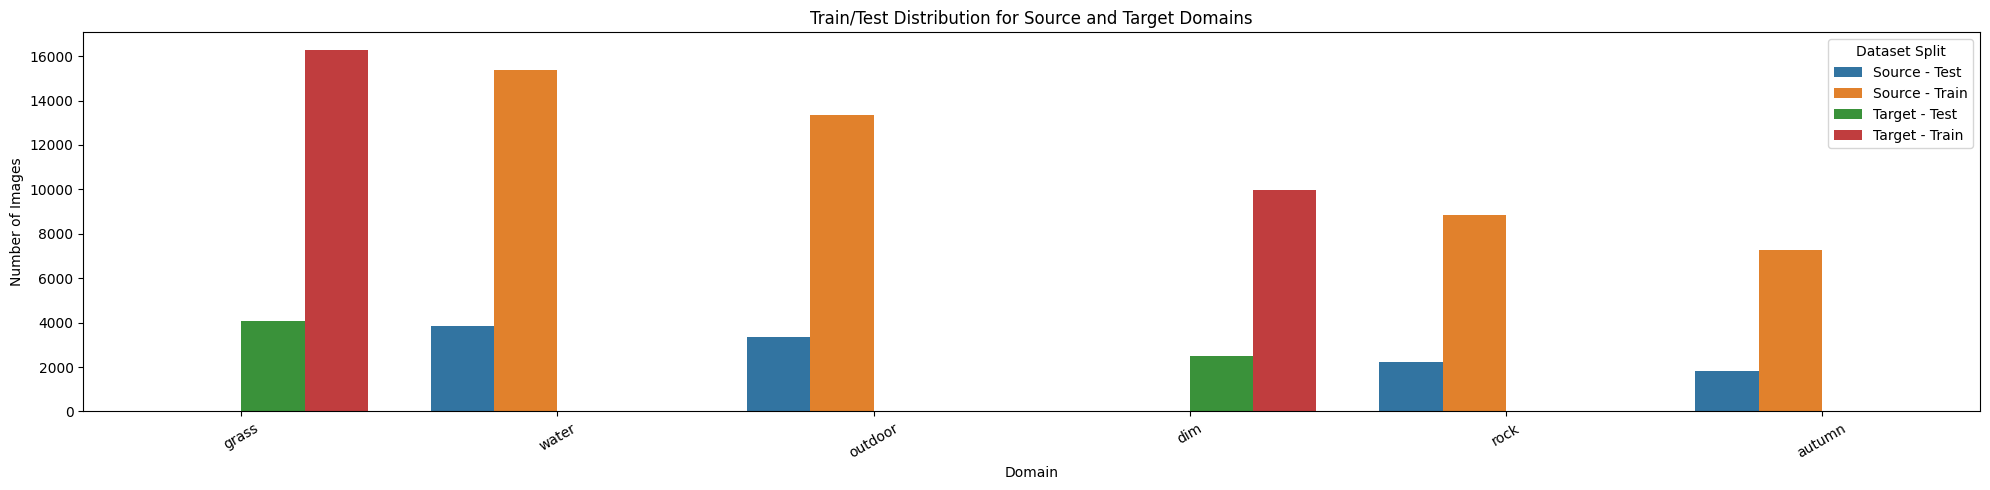

In [169]:
target_domains = ['dim', 'grass']
source_df, target_df = source_target_plot(target_domains)

In [173]:
target_path = Path(r"D:\Project\CPV_paper\datasets\processed\NICO++\dim_grass") # replace this

target_train_df = target_df[target_df["split"] == "train"]
target_test_df = target_df[target_df["split"] == "test"]

target_train_path = target_path / "train"
target_test_path = target_path / "test"

target_train_path.mkdir(parents=True, exist_ok=True)
target_test_path.mkdir(parents=True, exist_ok=True)

copy_images(target_train_df, root_path, target_train_path)
copy_images(target_test_df, root_path, target_test_path)

**Case 3**

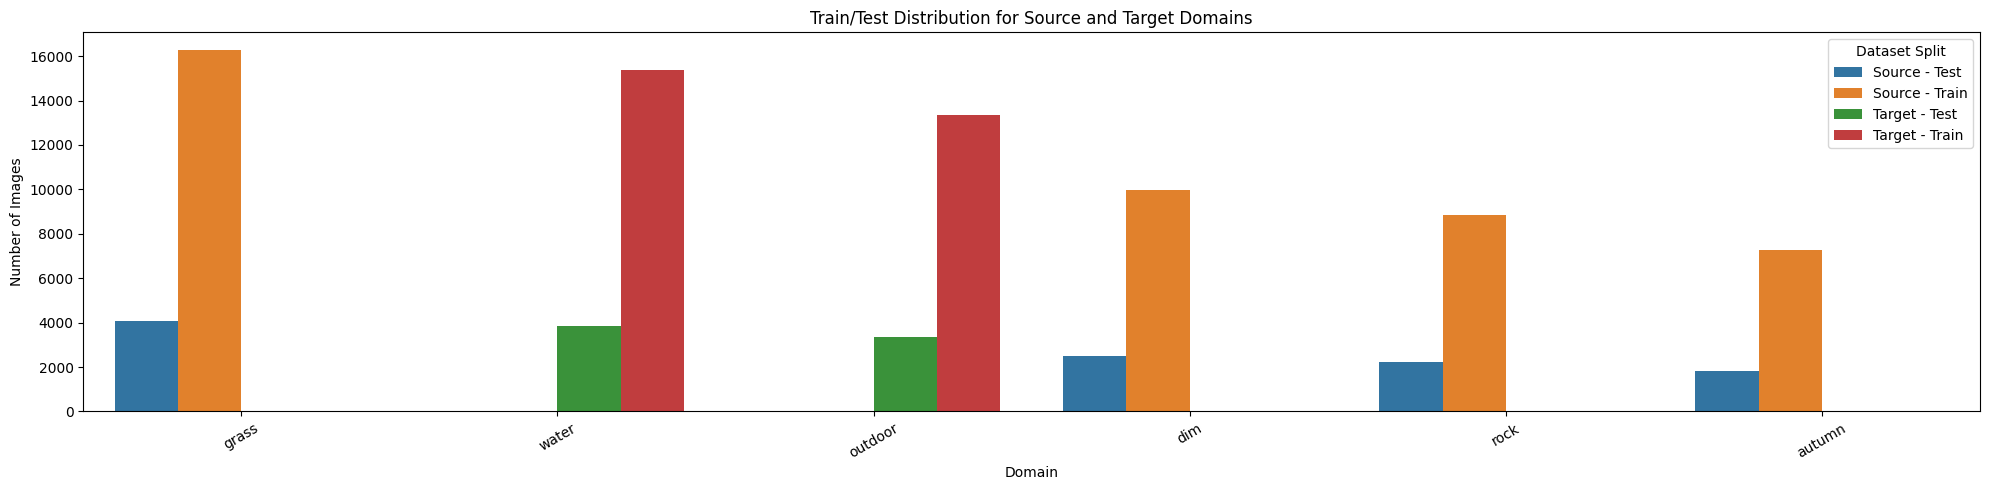

In [174]:
target_domains = ['outdoor', 'water']
source_df, target_df = source_target_plot(target_domains)

In [176]:
target_path = Path(r"D:\Project\CPV_paper\datasets\processed\NICO++\outdoor_water") # replace this

target_train_df = target_df[target_df["split"] == "train"]
target_test_df = target_df[target_df["split"] == "test"]

target_train_path = target_path / "train"
target_test_path = target_path / "test"

target_train_path.mkdir(parents=True, exist_ok=True)
target_test_path.mkdir(parents=True, exist_ok=True)

copy_images(target_train_df, root_path, target_train_path)
copy_images(target_test_df, root_path, target_test_path)